In [1]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("ecommerce_data.csv")
df

,Customer_ID,Gender,Age_Group,Purchase_Amount,Version
0,1,Male,18-25,500,Old
1,2,Female,26-35,700,New
2,3,Male,18-25,300,New
3,4,Female,36-45,900,Old
4,5,Male,26-35,650,New
5,6,Female,18-25,400,Old
6,7,Male,36-45,800,New
7,8,Female,26-35,720,New
8,9,Male,18-25,200,Old
9,10,Female,36-45,950,New


In [4]:
df.head()

,Customer_ID,Gender,Age_Group,Purchase_Amount,Version
0,1,Male,18-25,500,Old
1,2,Female,26-35,700,New
2,3,Male,18-25,300,New
3,4,Female,36-45,900,Old
4,5,Male,26-35,650,New


In [5]:
df.tail()

,Customer_ID,Gender,Age_Group,Purchase_Amount,Version
20,21,Male,18-25,310,New
21,22,Female,36-45,890,New
22,23,Male,26-35,660,Old
23,24,Female,18-25,430,New
24,25,Male,36-45,820,Old


In [6]:
df.isna()

,Customer_ID,Gender,Age_Group,Purchase_Amount,Version
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [8]:
df.isna().sum()

Customer_ID        0
Gender             0
Age_Group          0
Purchase_Amount    0
Version            0
dtype: int64

In [9]:
df.describe()

,Customer_ID,Purchase_Amount
count,25.000000,25.000000
mean,13.000000,626.000000
std,7.359801,219.544984
min,1.000000,200.000000
25%,7.000000,430.000000
50%,13.000000,660.000000
75%,19.000000,800.000000
max,25.000000,950.000000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Customer_ID      25 non-null     int64 
 1   Gender           25 non-null     object
 2   Age_Group        25 non-null     object
 3   Purchase_Amount  25 non-null     int64 
 4   Version          25 non-null     object
dtypes: int64(2), object(3)
memory usage: 1.1+ KB


do differnt age group spend differently?

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [14]:
df["Purchase_Amount"].unique()

array([500, 700, 300, 900, 650, 400, 800, 720, 200, 950, 600, 450, 780,
       680, 350, 920, 640, 420, 870, 710, 310, 890, 660, 430, 820])

In [18]:
group1 = df[df['Age_Group'] == '18-25']['Purchase_Amount']
group2 = df[df['Age_Group'] == '26-35']['Purchase_Amount']
group3 = df[df['Age_Group'] == '36-45']['Purchase_Amount']

In [20]:
f_stats,p_value=f_oneway(group1,group2,group3)
print(f_stats)

110.20300035718537


In [22]:
print(p_value)

3.440903218531885e-12


In [23]:
alpha=0.05

In [25]:
if p_value < alpha:
    print("reject null hypothesis,different age group spend differently")
else:
    print("accept null hypothesis ")

reject null hypothesis,different age group spend differently


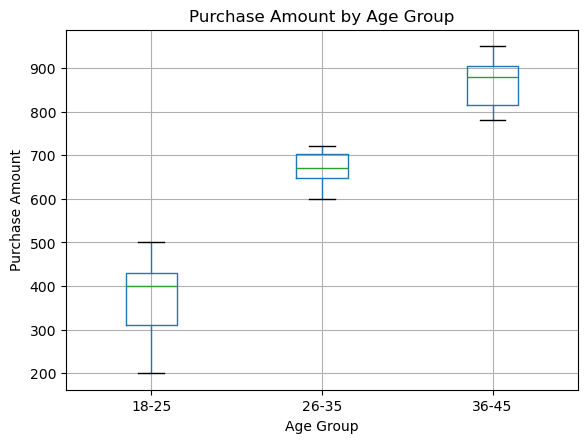

In [29]:
df.boxplot(column='Purchase_Amount', by='Age_Group')
plt.title("Purchase Amount by Age Group")
plt.suptitle("")  # remove default title
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")
plt.show()